# 03 - Transfert inter-instruments
### Data : Corn NIR (Cargill / Eigenvector)

La seconde question du projet : **un modèle entraîné sur `m5` fonctionne-t-il sur `mp5`/`mp6` ?** Et sinon, la Direct/Piecewise Standardization permet-elle de récupérer la performance ?

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from corn_nir.data import load_corn_mat
from corn_nir.experiments import run_calibration_transfer, run_cross_instrument_robustness
from corn_nir.visualization import plot_parity

pd.set_option("display.width", 160)
ds = load_corn_mat(ROOT / "data" / "raw" / "corn.mat")

RESULTS_DIR = ROOT / "reports" / "results"
FIGURES_DIR = ROOT / "reports" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Meilleur pretraitement par cible et performance de reference intra-instrument (m5),
# repris de la Partie D de 02_prediction_intra_instrument.ipynb (validation croisee
# leave-one-out imbriquee), pas recalcule ici pour eviter les 6 minutes de la
# comparaison complete des 7 pretraitements, deja faite dans ce notebook-la.
best_prep = {"Moisture": "raw", "Oil": "sg_deriv2", "Protein": "sg_deriv1", "Starch": "sg_deriv2"}
in_domain_reference = pd.DataFrame([
    {"target": "Moisture", "RMSE_mean": 0.0186, "R2_mean": 0.9976},
    {"target": "Oil", "RMSE_mean": 0.0300, "R2_mean": 0.9709},
    {"target": "Protein", "RMSE_mean": 0.0925, "R2_mean": 0.9652},
    {"target": "Starch", "RMSE_mean": 0.2283, "R2_mean": 0.9216},
])

## 1. Sans correction (Phase G) 

Pour chaque cible, on ajuste un modèle PLSR sur `m5` uniquement (meilleur prétraitement de la Partie D, composantes choisies par CV), puis on l'applique **directement**, sans aucune correction aux spectres `mp5`/`mp6` correspondants des mêmes 80 échantillons physiques.


Avant de lancer la fonction sur les 4 cibles x 2 instruments d'un coup, un exemple déroulé pour Protein/mp5 : les mêmes étapes que celles que `run_cross_instrument_robustness` répète en interne pour chaque combinaison :

In [2]:
from corn_nir.experiments import fit_m5_models
from corn_nir.evaluation import regression_metrics

# Un modele PLSR par cible, ajuste UNIQUEMENT sur m5 (jamais mp5/mp6), reutilise juste
# apres pour toutes les combinaisons cible x instrument.
m5_models_preview = fit_m5_models(ds, best_prep, max_components=10, inner_splits=5, random_state=0)
prep, model, best_n = m5_models_preview["Protein"]
print(f"Protein : pretraitement={best_prep['Protein']}, n_components choisi={best_n}")

# Applique tel quel (aucune correction) aux spectres mp5 des memes 80 echantillons physiques.
X_mp5_raw = ds.spectra["mp5"]
X_mp5_prep = prep.transform(X_mp5_raw) if prep is not None else X_mp5_raw
y_pred_example = model.predict(X_mp5_prep)
y_true_example = ds.targets["Protein"].values

m_example = regression_metrics(y_true_example, y_pred_example)
print(f"Protein / mp5, sans correction : RMSE={m_example['RMSE']:.3f}  R2={m_example['R2']:.3f}")

Protein : pretraitement=sg_deriv1, n_components choisi=8
Protein / mp5, sans correction : RMSE=0.798  R2=-1.592


Ce chiffre (RMSE=0.798, R2=-1.59) doit se retrouver dans la ligne Protein/mp5 du tableau complet ci-dessous : vérification que la fonction fait exactement ce qu'on vient de faire à la main, juste répétée pour les 4 cibles x 2 instruments.


In [3]:
no_correction_summary, m5_models = run_cross_instrument_robustness(
    ds, best_prep, max_components=10, inner_splits=5, random_state=0,
    in_domain_reference=in_domain_reference, verbose=False,
)
no_correction_summary.to_csv(RESULTS_DIR / "phase_g_cross_instrument_no_correction.csv", index=False)
no_correction_summary[["target", "test_instrument", "RMSE", "R2", "RPD", "in_domain_RMSE_mean"]].round(3)

,target,test_instrument,RMSE,R2,RPD,in_domain_RMSE_mean
0,Moisture,mp5,1.460,-13.925,0.260,0.019
1,Moisture,mp6,1.555,-15.919,0.245,0.019
2,Oil,mp5,0.282,-1.570,0.628,0.030
3,Oil,mp6,0.180,-0.048,0.983,0.030
4,Protein,mp5,0.798,-1.592,0.625,0.092
5,Protein,mp6,0.949,-2.672,0.525,0.092
6,Starch,mp5,1.386,-1.888,0.592,0.228
7,Starch,mp6,0.585,0.485,1.402,0.228


La performance **s'effondre** sur la plupart des combinaisons cible/instrument (R2 très négatif, pire qu'une simple moyenne) dès que l'instrument change, quelle que soit la qualité de l'ajustement en domaine (m5-vers-m5). Deux exceptions partielles : Oil/mp6 reste proche de zéro (R2=-0.05) et Starch/mp6 devient même légèrement positif (R2=0.49, RPD=1.40), toujours bien en dessous du seuil usuel d'utilisabilité (RPD>=2), pas un contre-exemple à la conclusion générale. Ceci confirme directement que le RPD spectaculaire de Moisture en domaine (notebook 02) ne reflète pas un signal chimique transférable.


## 2. Direct Standardization, Piecewise DS et Slope/Bias Correction (Phase H)

Les trois méthodes sont apprises sur 25 échantillons de maïs sélectionnés par Kennard-Stone par instrument (choisis pour la couverture spectrale) et évaluées sur les 55 restants jamais utilisés pour apprendre la transformation (`src/corn_nir/calibration_transfer.py`). DS et PDS corrigent les spectres avant prédiction ; Slope/Bias Correction (SBC) corrige directement les prédictions du modèle non corrigé, à partir des mêmes 25 échantillons de transfert. Réutilise les `m5_models` ajustés à l'étape 1 ci-dessus (pas besoin de les réajuster).


Avant la comparaison complète des 3 méthodes sur toutes les combinaisons, un exemple déroulé à la main pour Protein/mp5 : sélection des standards de transfert, ajustement de DS et SBC, puis correction :


In [4]:
from corn_nir.validation import kennard_stone_split
from corn_nir.calibration_transfer import DirectStandardization, SlopeBiasCorrection

# Kennard-Stone choisit 25 echantillons (sur les spectres mp5) qui couvrent bien la variabilite
# spectrale : ce sont les seuls dont on va utiliser la paire de spectres m5/mp5 pour apprendre
# la transformation. Les 55 autres ne serviront qu a evaluer, jamais a apprendre.
transfer_idx, eval_idx = kennard_stone_split(X_mp5_raw, n_train=25)
print(f"{len(transfer_idx)} echantillons de transfert, {len(eval_idx)} pour l'evaluation")

X_m5 = ds.spectra["m5"]
y = ds.targets["Protein"].values

def predict_on(X_slave_corrected):
    X_t = prep.transform(X_slave_corrected) if prep is not None else X_slave_corrected
    return model.predict(X_t)

y_true_eval = y[eval_idx]
y_pred_no_corr = predict_on(X_mp5_raw[eval_idx])

# DS : apprend une transformation des spectres (mp5 -> m5) sur les 25 standards de transfert.
ds_model = DirectStandardization(n_components=min(10, len(transfer_idx) - 1)).fit(
    X_mp5_raw[transfer_idx], X_m5[transfer_idx],
)
y_pred_ds = predict_on(ds_model.transform(X_mp5_raw[eval_idx]))

# SBC : apprend juste une droite (pente, biais) entre la prediction non corrigee sur les
# 25 standards de transfert et leur vraie valeur de reference.
sbc_model = SlopeBiasCorrection().fit(predict_on(X_mp5_raw[transfer_idx]), y[transfer_idx])
print(f"SBC ajuste : pente={sbc_model.slope_:.3f}, biais={sbc_model.intercept_:.3f}")
y_pred_sbc = sbc_model.transform(y_pred_no_corr)

for nom, y_pred in [("sans correction", y_pred_no_corr), ("DS", y_pred_ds), ("SBC", y_pred_sbc)]:
    m = regression_metrics(y_true_eval, y_pred)
    print(f"{nom:16s} RMSE={m['RMSE']:.3f}  R2={m['R2']:.3f}")

25 echantillons de transfert, 55 pour l'evaluation
SBC ajuste : pente=1.016, biais=0.655
sans correction  RMSE=0.800  R2=-1.331
DS               RMSE=0.187  R2=0.872
SBC              RMSE=0.129  R2=0.939


Ces chiffres (sans correction RMSE=0.800 ; DS=0.187 ; SBC=0.129) doivent se retrouver dans la ligne Protein/mp5 du tableau complet ci-dessous : même logique, juste déroulée à la main pour un cas avant de la lancer sur les 4 cibles x 2 instruments.


In [5]:
transfer_summary, pivot_summary, examples = run_calibration_transfer(
    ds, best_prep, max_components=10, inner_splits=5, n_transfer=25,
    random_state=0, models=m5_models, verbose=False,
)
transfer_summary.to_csv(RESULTS_DIR / "phase_h_calibration_transfer.csv", index=False)
pivot_summary.to_csv(RESULTS_DIR / "phase_h_no_transfer_vs_transfer_rmse.csv", index=False)
pivot_summary.round(4)

method,target,slave_instrument,DS,DS_nbs_standards_exploratory,PDS,SBC,no_correction
0,Moisture,mp5,0.1711,8.8042,0.2302,0.2004,1.4392
1,Moisture,mp6,0.1634,7.6834,0.3581,0.2400,1.5057
2,Oil,mp5,0.1202,8.3107,0.5985,0.0787,0.2885
3,Oil,mp6,0.1169,22.7895,0.8067,0.0780,0.1822
4,Protein,mp5,0.1874,7.2929,0.6388,0.1290,0.8001
5,Protein,mp6,0.1649,9.0162,0.4620,0.1219,0.9345
6,Starch,mp5,0.4150,119.5955,1.4941,0.3097,1.3712
7,Starch,mp6,0.4294,229.5550,1.7775,0.3096,0.5606


**SBC (le plus simple des trois, 2 paramètres) devance DS pour Oil, Protein et Starch** (ex. Protein : RMSE=0.129/0.122 vs DS 0.187/0.165 sur mp5/mp6). Seule Moisture fait exception, où DS reste meilleure (0.171/0.163 vs SBC 0.200/0.240). **La PDS reste la moins bonne des trois dans tous les cas**, parfois même pire que l'absence de correction pour les cibles dont le meilleur prétraitement est une dérivée (Oil, Protein, Starch).

Un même diagnostic explique les deux constats : DS et PDS corrigent les spectres bruts, mais cette correction n'est jamais parfaite sur seulement 25 échantillons de transfert, il reste toujours un résidu. Pour Oil/Protein/Starch, le meilleur prétraitement est une *dérivée* Savitzky-Golay, qui amplifie justement ce type de résidu haute fréquence (le plus fortement pour PDS, dont les fenêtres locales ne sont pas contraintes à la cohérence entre elles ; plus modérément pour DS). Pour Moisture (prétraitement `raw`, pas de dérivée), ce résidu n'est pas amplifié, et la correction plus riche de DS (jusqu'à 10 composantes PLS, contre 2 paramètres pour SBC) peut alors faire mieux. SBC, en corrigeant directement la prédiction plutôt que le spectre, ne souffre pas de cet effet d'amplification, ce qui explique son avantage précisément sur les cibles à dérivée. C'est un constat réel et reproductible sur ce dataset, pas une affirmation reprise de la littérature.

Recommandation empirique : SBC par défaut pour Oil/Protein/Starch, DS pour Moisture. PDS n'est recommandée pour aucune cible ici.


### Avant / après, Protein / mp5 : sans correction, DS, PDS et SBC côte à côte


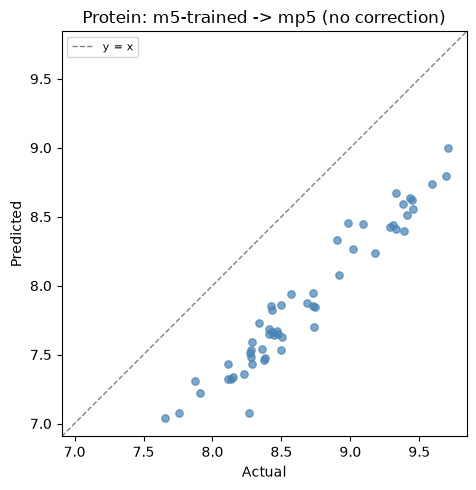

In [6]:
y_eval, y_pred_no_corr, y_pred_ds, y_pred_pds, y_pred_sbc = examples[("Protein", "mp5")]
fig = plot_parity(y_eval, y_pred_no_corr, title="Protein: m5-trained -> mp5 (no correction)")
fig.savefig(FIGURES_DIR / "parity_no_correction_protein_mp5.png", dpi=200)

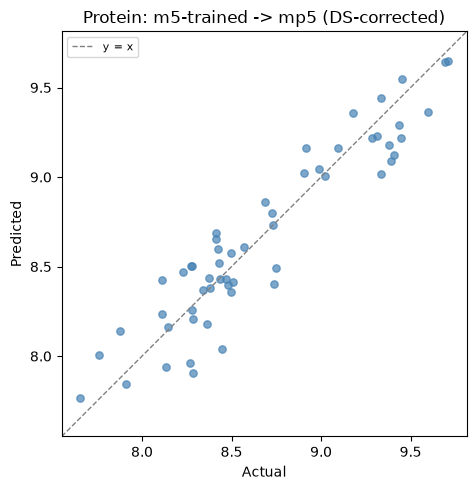

In [7]:
fig = plot_parity(y_eval, y_pred_ds, title="Protein: m5-trained -> mp5 (DS-corrected)")
fig.savefig(FIGURES_DIR / "parity_ds_corrected_protein_mp5.png", dpi=200)

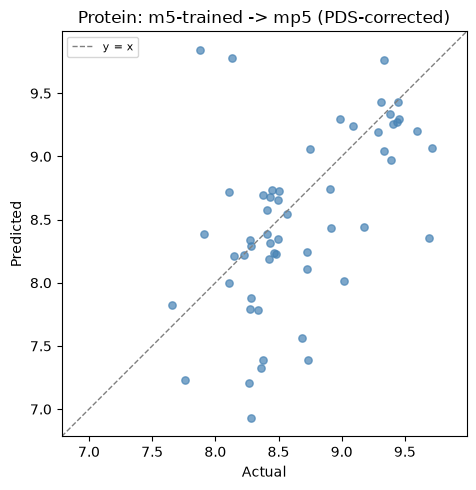

In [8]:
fig = plot_parity(y_eval, y_pred_pds, title="Protein: m5-trained -> mp5 (PDS-corrected)")
fig.savefig(FIGURES_DIR / "parity_pds_corrected_protein_mp5.png", dpi=200)

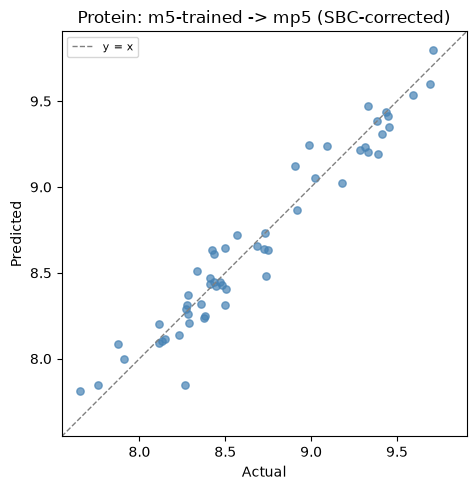

In [9]:
fig = plot_parity(y_eval, y_pred_sbc, title="Protein: m5-trained -> mp5 (SBC-corrected)")
fig.savefig(FIGURES_DIR / "parity_sbc_corrected_protein_mp5.png", dpi=200)

Le nuage SBC est nettement resserré, proche de celui de DS (cohérent avec le tableau ci-dessus : SBC bat même DS pour Protein). Le nuage PDS n'est visiblement pas plus resserré que celui sans correction, parfois pire, alors que DS et SBC se rapprochent nettement de la droite y=x. C'est le diagnostic d'amplification de bruit ci-dessus, rendu visible plutôt que simplement affirmé.


## 3. Standards NBS - exploratoire, et une mise en garde

La fiche du projet demande explicitement si les standards de verre NBS fournis avec le dataset peuvent
remplacer des échantillons de maïs comme standards de transfert.

In [10]:
nbs_rows = transfer_summary[transfer_summary["method"] == "DS_nbs_standards_exploratory"]
nbs_rows[["target", "slave_instrument", "RMSE", "R2"]].round(3)

,target,slave_instrument,RMSE,R2
4,Moisture,mp5,8.804,-627.854
9,Moisture,mp6,7.683,-576.398
14,Oil,mp5,8.311,-2141.465
19,Oil,mp6,22.789,-16377.695
24,Protein,mp5,7.293,-192.658
29,Protein,mp6,9.016,-298.438
34,Starch,mp5,119.595,-20173.054
39,Starch,mp6,229.555,-82741.063


**Bien pire que l'absence de correction** (RMSE jusqu'à 230). Deux limites qui se cumulent : seulement
3 standards appariés utilisables (`m5nbs` a 3 lignes, `mp5nbs`/`mp6nbs` en ont 4. Un écart de comptage
inexpliqué dans le fichier source, donc l'appariement utilisé ici est une hypothèse positionnelle naïve,
non vérifiée), et le verre a une matrice optique fondamentalement différente du maïs. Conservé dans les
résultats par souci de transparence, pas comme méthode utilisable.

## Résumé

Voir le [README](../README.md) du projet pour le tableau récapitulatif complet sur toutes les phases.
